# Data integration and meta-analysis of birthweights

This notebook illustrates some methods for meta-analysis and data integration, using the NCHS birth data.  See [here](https://github.com/kshedden/case_studies/blob/main/birthweight/birthweight.ipynb) for background information about the data.

Throughout this notebook, we will be partitioning the population into subpopulations based on geography, time, and demographics.  Within each subpopulation we will construct statistical summaries of the birthweight and parental ages, which are viewed as outcomes. Then we will assess how these outcomes vary across the subpopulations.  This is an example of data integration or "complete data meta-analysis", since we have access to the individual level data as well as the subpopulation summaries.  Most of the methods demonstrated below would also be applicable if we only had access to the summary statistics.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import local_fdr
from statsmodels.nonparametric.smoothers_lowess import lowess

Set the cell below to point to the location of all data paths.

In [2]:
pa = ""
pa = Path(pa)

We will use data from four years.

In [3]:
years = [1971, 1981, 1991, 1992]
dax = [pd.read_csv(pa / f"{year}.csv.gz") for year in years]
da = pd.concat(dax, axis=0)
da = da[[x for x in da.columns if not (x in ["smsa", "msa"])]]
dax = None

A core set of variables should always be present, so we drop observations with missing values on any of these variables.

In [4]:
ii = da[["year", "state", "county", "sex", "birthorder", "momrace", "momage", "birthweight"]].notnull().all(axis=1)
da = da.loc[ii, :]
da.shape

(13147594, 13)

This is what a few observations look like:

In [5]:
da.head()

,year,state,county,sex,dadrace,momrace,momage,birthorder,dadage,birthweight,plurality,interval,popsize
0,1971,1,001,male,White,White,20,1.0,22.0,4196.0,1,NaN,9
1,1971,1,002,male,White,White,27,3.0,27.0,2920.0,1,NaN,9
2,1971,1,002,female,Black,Black,20,3.0,30.0,2892.0,1,NaN,9
3,1971,1,002,male,White,White,28,5.0,32.0,3232.0,1,NaN,9
4,1971,1,002,male,White,White,30,3.0,26.0,3175.0,1,NaN,9


We allow paternal variables to be missing, and the "interval" variable (time to the mother's previous birth) is always missing for first births since it is undefined.

In [6]:
da.isnull().sum(0)

year                 0
state                0
county               0
sex                  0
dadrace        1762705
momrace              0
momage               0
birthorder           0
dadage         1920253
birthweight          0
plurality            0
interval       6237619
popsize              0
dtype: int64

Some of the birthorder values are implausible, so we clip them at 10.

In [7]:
da["birthorder"] = da["birthorder"].clip(1, 10)

Plurality and birthorder have strong and generally well-understood impacts on birthweight.  For simplicity, in this analysis we consider only first born single births so that we do not have to account for these effects.

In [8]:
da = da.query("birthorder == 1 & plurality == 1")

## Data integration over spacial/demographic sub-populations

The births occur in US counties, which are uniquely defined by their numeric state and county codes.  We combine the two here to produce a single code that uniquely defines each US county.

In [9]:
da["loc"] = [f"{state}_{county}" for (state, county) in zip(da["state"], da["county"])]
print(len(da["loc"].unique()))

3197


We begin by considering the evidence for heterogeneity between subpopulations defined by geography and demographics, where geography is based on state/county and demographics is based on year, sex, and maternal race.  These are all categorical variables that jointly partition the population into $n \times 4 \times 2 \times 4 = 32\cdot n$ subpopulations, where $n \approx 3100$ is the number of counties. Some strata have little or no data so are not included in the table.

We have three quantitative measures of interest: birthweight, maternal age, and paternal age.  We begin by summarizing the distributions of these four measures within subpopulations.  We will use the sample mean and the sample standard deviation to capture these two features of each distribution, restricting ourselves to subpopulations with sufficient information to estimate a dispersion parameter.

In [10]:
fl = ["mean", "std", "size"]
dg = da.groupby(["loc", "year", "sex", "momrace"]).agg({"birthweight": fl, "momage": fl, "dadage": fl})
dg = dg[dg[("birthweight", "size")] >= 2]
dg

birthweight                       momage  \
                                   mean         std  size       mean   
loc    year sex    momrace                                             
10_001 1971 female Black    2992.320755  487.068617    53  18.339623   
                   White    3301.532051  498.974968   156  22.115385   
            male   Black    3042.222222  515.958975    36  18.972222   
                   White    3489.140244  540.861820   164  22.213415   
       1981 female Asian    3061.666667  283.500147     3  28.000000   
...                                 ...         ...   ...        ...   
9_001  1992 female Black    3076.309229  585.416429  1051  21.947669   
                   White    3349.449827  435.756596   289  29.712803   
            male   Asian    3353.406593  485.989711    91  24.780220   
                   Black    3187.950244  620.957931  1025  21.809756   
                   White    3423.678571  526.942607   336  29.485119   

                                               dadage                  
                                 std  size       mean       std  size  
loc    year sex    momrace                                             
10_001 1971 female Black    2.659839    53  22.222222  2.921634    53  
                   White    3.825149   156  23.959184  3.904472   156  
            male   Black    3.112061    36  25.500000  8.860023    36  
                   White    3.686762   164  24.496774  4.192408   164  
       1981 female Asian    1.000000     3  27.333333  3.511885     3  
...                              ...   ...        ...       ...   ...  
9_001  1992 female Black    5.761789  1051  27.687679  7.120667  1051  
                   White    5.821167   289  32.938697  6.644552   289  
            male   Asian    5.755774    91  29.357143  6.325787    91  
                   Black    5.713873  1025  27.394937  7.525319  1025  
                   White    5.891032   336  33.167224  6.940698   336  

[26337 rows x 9 columns]

Since our focus here is on data integration, the information available to us is reflected in both the number of subpopulations, and the number of births (sample size) per subpopulation.  The empirical quantile function below shows the distribution of the number of births per subpopulation.

Text(0, 0.5, 'log10 birth count')

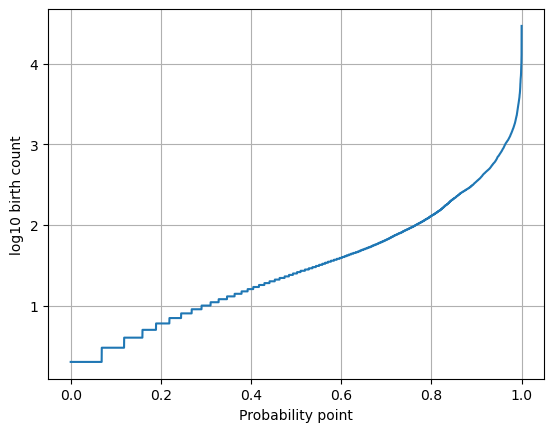

In [11]:
pp = np.linspace(0, 1, dg.shape[0])
y = np.sort(np.log10(dg[("birthweight", "size")]))
plt.grid(True)
plt.plot(pp, y, "-")
plt.xlabel("Probability point")
plt.ylabel("log10 birth count")

We will also need the standard error of the mean for each county.

In [12]:
for vname in ["birthweight", "momage", "dadage"]:
     dg[(vname, "se")] = dg[(vname, "std")] / np.sqrt(dg[(vname, "size")])
dg = dg.sort_index(axis=1)
dg.head()

birthweight                               \
                                   mean          se size         std   
loc    year sex    momrace                                             
10_001 1971 female Black    2992.320755   66.904020   53  487.068617   
                   White    3301.532051   39.949970  156  498.974968   
            male   Black    3042.222222   85.993162   36  515.958975   
                   White    3489.140244   42.234213  164  540.861820   
       1981 female Asian    3061.666667  163.678886    3  283.500147   

                               dadage                              momage  \
                                 mean        se size       std       mean   
loc    year sex    momrace                                                  
10_001 1971 female Black    22.222222  0.401317   53  2.921634  18.339623   
                   White    23.959184  0.312608  156  3.904472  22.115385   
            male   Black    25.500000  1.476670   36  8.860023  18.972222   
                   White    24.496774  0.327372  164  4.192408  22.213415   
       1981 female Asian    27.333333  2.027588    3  3.511885  28.000000   

                                                     
                                  se size       std  
loc    year sex    momrace                           
10_001 1971 female Black    0.365357   53  2.659839  
                   White    0.306257  156  3.825149  
            male   Black    0.518677   36  3.112061  
                   White    0.287888  164  3.686762  
       1981 female Asian    0.577350    3  1.000000

### Intraclass correlation

A common parameter for assessing heterogeneity in clustered data is the [intraclass correlation coefficient](https://en.wikipedia.org/wiki/Intraclass_correlation) (ICC).  Working with the ICC amounts to a special case of _variance components analysis_, which we will discuss in more detail below.  The ICC is often assessed using restricted maximum likelilhood estimation of mixed effects regression models, but here we will use a simpler estimation approach based on moments.

As seen above, US counties vary dramatically in population size.  The county size should not bias the estimation of the ICC, but it is possible that there is a systematic relationship between county size and the ICC, so we estimate the ICC using various levels of filtering based on minimum population size.

In [13]:
def get_icc(dg, vname):
    means = dg[(vname, "mean")]
    varis = dg[(vname, "std")]**2
    svars = dg[(vname, "se")]**2
    b, w = np.var(means) - np.mean(svars), np.mean(varis)
    return b / (b + w)

vnames = ["birthweight", "momage", "dadage"]
n_mins = [20, 50, 100, 500, 1000, 2000]

rslt = []
for n_min in n_mins:
    row = []
    for vname in ["birthweight", "momage", "dadage"]:
        dg1 = dg[dg[("birthweight", "size")] >= n_min]
        icc = get_icc(dg1, vname)
        row.append(icc) 
    rslt.append(row)

rslt = pd.DataFrame(rslt, columns=vnames, index=n_mins)
print(rslt)

      birthweight    momage    dadage
20       0.054948  0.187764  0.140510
50       0.050499  0.165905  0.122852
100      0.049555  0.150597  0.107671
500      0.041188  0.137159  0.092230
1000     0.041436  0.131357  0.084878
2000     0.035381  0.114263  0.072500


One way to interpret the ICC is based on it being the proportion of the total variance of an outcome that varies between groups rather than within groups.  Maternal age has the strongest subpopulation variation (ICC) in this sense.  Below we calculate the total variance of maternal age, then compute the proportion of the total variance that is between groups (based on the ICC values above), and finally convert this to a standard deviation for easier interpretation.  We get a value of around 2.3, which means that if the subpopulation means are normal, comparing a sub-population in the upper 15% to one in the lower 15% (+1SD versus -1SD), the difference in mean maternal ages between these sub-populations would be around 4.6 years.  The ICC remains valid even if the data are not normal, but this simple interpretation of the ICC depends on normality.

In [14]:
np.sqrt(da["momage"].var() * rslt["momage"].iloc[0])

2.2700660035606277

Above we used an adjusted variance to obtain the ICC, which we discuss in more detail now.  Suppose that $\theta_i$ is a parameter that varies over subpopulations indexed by $i$.  It may be of interest to quantify ${\rm var}(\theta_i)$, the variation of the value of this parameter over the subpopulations, which is the numerator of the ICC.  To accomplish this, suppose we have an unbiased estimate $\hat{\theta}_i$ of $\theta_i$.  We can write $\hat{\theta}_i = \theta_i + \eta_i$, where $\eta_i$ is the estimation error, so ${\rm var}(\eta_i) = {\rm SE}_i^2$, where ${\rm SE}_i$ is the standard error for $\hat{\theta}_i$.  It follows that ${\rm var}(\hat{\theta}_i) = {\rm var}E(\hat{\theta}_i|\theta_i) + E {\rm var}(\hat{\theta}_i | \theta_i)$, where ${\rm var}(\hat{\theta}_i)$ encompasses variance both over $i$ (structural variance) and within $i$ (estimation variance).  This allows use to use $\widehat{\rm var}(\hat{\theta}_i) - {\rm Avg}(\{{\rm SE}_i^2\})$ to estimate ${\rm var}(\theta_i)$.  

Above we used this estimation approach to obtain debiased ICC values, but we can also interpret the debiased estimate of ${\rm var}(\theta_i)$, or of ${\rm SD}(\theta_i)$ directly.  Below we do this analysis using three outcome variables.  To assess for systematic differences based on subpopulation size, we consider four different lower bounds on the sample size that are used to define the subpopulations used in the analysis.  For each threshold, we present the debiased standard deviation (e.g. 'birthweight') and the unadjusted standard deviation (with an 'x' appended to the variable name, e.g. 'birthweightx').

In [15]:
vnames1 = ["birthweight", "birthweightx", "momage", "momagex", "dadage", "dadeagex"]
rslt = []

for n_min in n_mins:
    row = []
    dg1 = dg[dg[("birthweight", "size")] >= n_min]
    for vname in vnames:
        b, w = np.var(dg1[(vname, "mean")]), np.mean(dg1[(vname, "se")]**2)  
        pva = b - w
        pse = np.sqrt(pva) if pva >= 0 else 0
        row.append(pse)
        row.append(np.sqrt(b))
    rslt.append(row)
rslt = pd.DataFrame(rslt, columns=vnames1, index=n_mins)
print(rslt)

      birthweight  birthweightx    momage   momagex    dadage  dadeagex
20     132.320429    150.466555  2.063357  2.130669  2.149648  2.254735
50     127.178159    135.888317  1.988227  2.021745  2.022258  2.072836
100    126.464561    131.264111  1.951383  1.971563  1.922751  1.953006
500    114.251497    115.607569  1.969365  1.975588  1.836266  1.845357
1000   115.016775    115.808342  1.963767  1.967641  1.787706  1.793413
2000   106.131746    106.567430  1.812365  1.814447  1.653209  1.656336


Above we focused on the ICC, which is defined in terms of the subpopulation means, but the approach can be applied more generally.  We now show how a statistic other than the mean can be assessed in terms of how much it varies between sub-populations.  For illustration, we consider the [Kendall's tau correlation](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) between maternal age and birthweight.  We restrict the analysis to mother's of age 30 and under, since the relationship between maternal age and birthweight is suspected to be non-monotone, with lower average birthweights occurring for both younger and older mothers.  By restricting to the younger than average mothers, we isolate the monotone risk associated with young motherhood.  We first estimate the value of the Kendall's tau correlation at the level of individual births.

In [16]:
da1 = da.query("momage <= 30")
stats.kendalltau(da1["birthweight"], da1["momage"])

SignificanceResult(statistic=0.07285174229949007, pvalue=0.0)

Next we consider the tau correlation values within each subpopulation.

In [17]:
def f(x):
    # Returns kendall's tau: sample size, statistic, p-value, standard error
    k = stats.kendalltau(x["birthweight"], x["momage"])
    n = len(x)
    se = np.nan if n <= 1 else np.sqrt(2*(2*n+5) / (9*n*(n-1)))
    return pd.Series([n, k[0], k[1], se])

dg = da1.groupby(["loc", "year", "sex", "momrace"])
dh = dg.apply(lambda x: f(x))
dh.columns = ["n", "cor", "p", "se"]
dh = dh.query("n >= 200")
dh

n       cor         p        se
loc    year sex    momrace                                      
10_001 1981 female White     277.0  0.034637  0.408167  0.040309
            male   White     331.0  0.045667  0.232437  0.036837
       1991 female White     206.0  0.081771  0.092249  0.046844
            male   White     232.0  0.000931  0.983749  0.044099
10_003 1981 female White     262.0 -0.040050  0.357776  0.041462
...                            ...       ...       ...       ...
9_001  1981 male   Black     836.0 -0.002710  0.910607  0.023105
       1991 female Black    1123.0 -0.000737  0.971636  0.019925
            male   Black    1194.0  0.013188  0.512105  0.019322
       1992 female Black     945.0  0.053855  0.017303  0.021727
            male   Black     926.0  0.024303  0.287673  0.021949

[3922 rows x 4 columns]

The results below indicate that a typical subpopulation has a correlation of around 0.05, and that the estimated tau correlations fluctuate from county to county with an SD around 0.04.

In [18]:
print(dh["cor"].mean())
print(dh["cor"].std())

0.04512357397428513
0.03768095851278579


However the SD in the estimated tau correlations is biased upward relative to the structure SD.  To assess the structureal SD, we remove the effect of sampling variation due to finite sample sizes within each stratum.  This gives us a smaller but more meaningful SD, which implies that (under normality, to facilitate interpretation), some subpopulations may have correlations as low as 0.01 (the mean minus two times the standard deviation), or as high as 0.09 (the mean plus two times the standard deviation).

In [19]:
np.sqrt(np.var(dh["cor"]) - np.mean(dh["se"]**2))

0.01850319930151212

### False Discovery rates

We will now consider the strength of evidence for the association between maternal age and birthweight within strata.  The main tool to be employed here is the [local false discovery rate](https://www.efron.ckirby.su.domains/papers/2005LocalFDR.pdf), or local FDR.  This approach focuses on the distribution of Z-scores, where a Z-score is an estimated tau correlation coeffient divided by its standard error.  Under the global null hypothesis (all subpopulation correlations are zero), these Z-scores approximately follow a standard normal distribution, due to the sample correlation coefficient being asymptotically normal in distribution.  The histogram below shows that the observed Z-scores are shifted to the right and more dispersed than a standard normal distribution, so from this visual perspective, the global null hypothesis does not seem to hold.

Text(0, 0.5, 'Frequency')

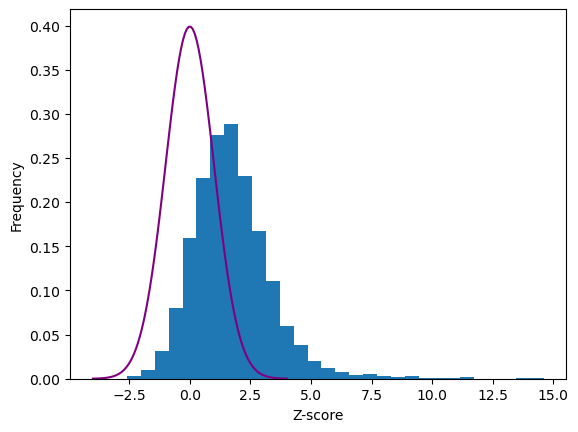

In [20]:
dh["Z"] = dh["cor"] / dh["se"]
plt.hist(dh["Z"], density=True, bins=30)
x = np.linspace(-4, 4, 100)
y = stats.norm().pdf(x)
plt.plot(x, y, "-", color="purple")
plt.xlabel("Z-score")
plt.ylabel("Frequency")

The mean Z-score is much greater than 0, and the standard deviation of Z-scores is much greater than 1, strongly suggesting that the global null hypothesis is false.

In [21]:
print(dh["Z"].mean())
print(dh["Z"].std())

1.7511737184165077
1.6715427548702584


Another perspective on the distribution of Z-scores follows from inspection of the quantiles.  The plot below shows the empirical quantiles (blue) and the standard normal quantiles (purple).

Text(0, 0.5, 'Z-score')

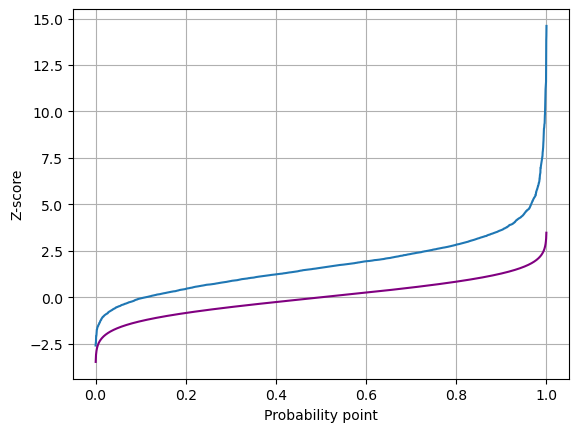

In [22]:
z = np.sort(dh["Z"])
pp = np.linspace(0, 1, len(z))
g = [stats.norm().ppf(p) for p in pp]
plt.grid(True)
plt.plot(pp, z, "-")
plt.plot(pp, g, "-", color="purple")
plt.xlabel("Probability point")
plt.ylabel("Z-score")

Recall that the local FDR for a specific observation (here a subpopulation) can be estimated as the ratio between the reference null density of the statistic (here standard normal) and the empirical density of all statistic values.  Conventionally, ratios below 0.05-0.1 are deemed to be small.  

Text(0, 0.5, 'local FDR')

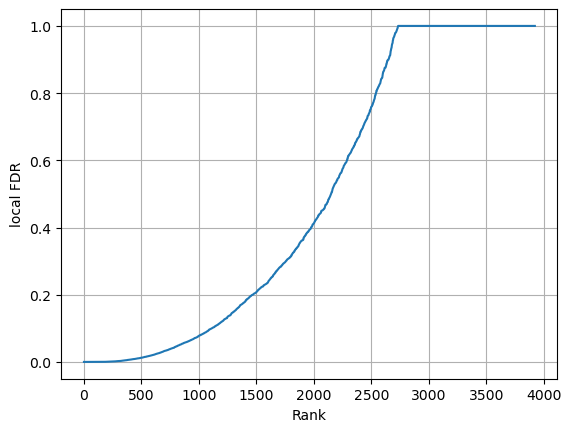

In [23]:
lfdr = local_fdr(dh["Z"])
plt.grid(True)
plt.plot(np.sort(lfdr.values))
plt.xlabel("Rank")
plt.ylabel("local FDR")

Some of the FDRs might be large due to low power, which occurs when the sample size in a given subpopulation is small.  The plot below shows that the FDRs tend to decrease with increasing sample size.  However there are numerous small local FDR values for smaller as well as larger sample sizes.  

Text(0, 0.5, 'Logit local FDR')

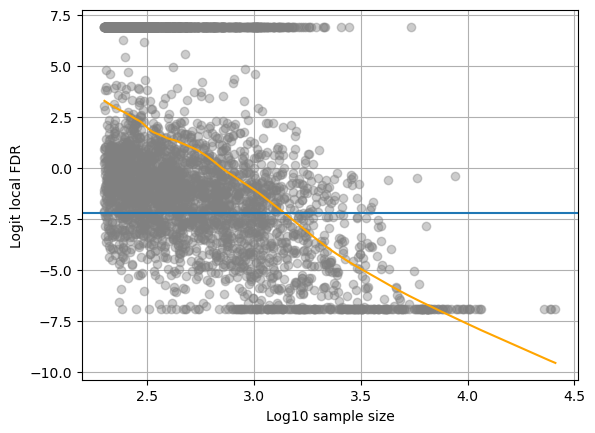

In [24]:
def clogit(x):
    x = np.clip(x, 0.001, 0.999)
    return np.log(x / (1 - x))

plt.grid(True)
x, y = np.log10(dh["n"]), clogit(lfdr)
xy = lowess(y, x, 0.3)
plt.plot(x, y, "o", color="grey", alpha=0.4)
plt.plot(xy[:, 0], xy[:, 1], "-", color="orange")
plt.axhline(clogit(0.1))
plt.xlabel("Log10 sample size")
plt.ylabel("Logit local FDR")

## Empirical likelihood

In this section we consider a more sophisticated set of approaches for quantifying subpopulation heterogeneity, based on the [jackknife](https://en.wikipedia.org/wiki/Jackknife_resampling) and [empirical likelihoods](https://en.wikipedia.org/wiki/Empirical_likelihood).  The parameter of interest here is $\tau^2 = {\rm Var}E[Y|X]$, where $X$ denotes groups and $Y$ denotes a quantitative outcome that is measured repeatedly within each group.  The parameter $\tau^2$ captures the dispersion of subpopulation means.  In practice it will often be interpreted on the standard deviation scale, yielding ${\rm SD}(E[Y|X])$, but estimation and inference is easier to carry out on the variance scale.

As discussed above, we can unbiasedly estimate $\tau^2$ using $\hat{\tau}^2 = \widehat{\rm var}(\hat{\theta}_i) - {\rm Avg}_i {\rm SE}_i$, where the second term corrects for the upward bias in the first term due to estimation variance in the $\hat{\theta}_i$.  To better understand the precision with which this quantity is estimated, we can use a jackknifing procedure.  Specifically, let $\check{\tau}^2_i$ denote the estimate of $\tau^2$ obtained when omitting group $i$ (the _deleted estimate_ for case $i$), and let $\tilde{\tau}^2_i = n\hat{\tau}^2 - (n-1)\check{\tau}^2_i$, where $n$ is the sample size.  The $\tilde{\tau}^2_i$ are known as the _jackknife pseudo-observations_, and have the property that ${\rm SD}(\tilde{\tau}^2_i) / \sqrt{n}$ is appoximately equal to the sampling standard deviation of $\hat{\tau}^2$, that is, its standard error.  The average of the pseudo-observations will generally be close to, or exactly equal to the estimate $\hat{\tau}^2$ that uses all of the data.

Below we calculate the deleted estimates and pseudo-observations, using some basic algebra to accelerate the computations.

In [25]:
outvar = "birthweight"

def delete_mean(x):
    s = x.sum()
    n = len(x)
    return (s - x) / (n - 1)

# Calculate some statistics deleting each location in turn
def setup_jackstats(outvar, da):
    dg = da.groupby("loc").agg({outvar: [np.mean, np.std, len]})
    dg[(outvar, "se")] = dg[(outvar, "std")] / np.sqrt(dg[(outvar, "len")])
    n = dg.shape[0]
    dg[(outvar, "mean1_del")] = delete_mean(dg[(outvar, "mean")])
    dg[(outvar, "mean2_del")] = delete_mean(dg[(outvar, "mean")]**2)
    dg[(outvar, "msva_del")] = delete_mean(dg[(outvar, "se")]**2)
    dg[(outvar, "varmean_del")] = dg[(outvar, "mean2_del")] - dg[(outvar, "mean1_del")]**2
    dg[(outvar, "locvar_del")] = dg[(outvar, "varmean_del")] - dg[(outvar, "msva_del")]

    locvar0 = np.var(dg[(outvar, "mean")]) - np.mean(dg[(outvar, "se")]**2)
    locvar = dg[(outvar, "locvar_del")].mean()
    dg[(outvar, "locvar_pseudo")] = n*locvar - (n-1)*dg[(outvar, "locvar_del")]
    return dg, locvar0

The point estimate and jackknife standard error for $\tau^2$ are below. 

In [26]:
dg, locvar0 = setup_jackstats(outvar, da)
pseudo = dg[(outvar, "locvar_pseudo")].values

jmn = np.mean(pseudo)
jse = np.std(pseudo) / np.sqrt(len(pseudo))
print(jmn)
print(jse)

/tmp/ipykernel_3109168/1148708658.py:10: FutureWarning: The provided callable <function mean at 0x14a2a0093380> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  dg = da.groupby("loc").agg({outvar: [np.mean, np.std, len]})
/tmp/ipykernel_3109168/1148708658.py:10: FutureWarning: The provided callable <function std at 0x14a2a00934c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  dg = da.groupby("loc").agg({outvar: [np.mean, np.std, len]})


4457.813493901853
306.1606582495264


Taking this a step further, we can construct confidence intervals for the parameter $\tau^2$ (and for $\tau$) using the _jackknife empirical likelihood_ approach.  This is mostly useful for smaller sample sizes, where the computations are faster and the asymptotic interval does not cover well.  So we subsample the counties below to illustrate.

In [27]:
from scipy.optimize import minimize
from scipy.stats import distributions as dist

uloc = da["loc"].unique()[0:200]
da1 = da.loc[da["loc"].isin(uloc), :]
dg, locvar0 = setup_jackstats(outvar, da1)
pseudo = dg[(outvar, "locvar_pseudo")].values

# Use these as a guide for where to evaluate the likelihood
jmn = np.mean(pseudo)
jse = np.std(pseudo) / np.sqrt(len(pseudo))

# Negative log-likelihood
def nll(x):
    return -np.log(x).sum()

def nll_grad(x):
    return -1/x

# Coefficient matrix for the constraints
m = len(pseudo)
A = np.zeros((2, m))
A[0, :] = 1
A[1, :] = pseudo

# The log-likelihood function.
def llprof(t2):
    eq_cons = {"type": "eq", "fun": lambda x: np.dot(A, x) - np.r_[1, t2], "jac": lambda x: A}
    bnds = [(1e-10, None) for _ in range(m)]
    x0 = np.ones(m) / m
    r = minimize(nll, x0, jac=nll_grad, constraints=[eq_cons], bounds=bnds, method="SLSQP", options={"maxiter": 1000})
    return r

# The profile empirical likelihood
nfail = 0
rslt = []
for t2 in np.linspace(jmn - 3*jse, jmn + 4*jse, 20):
    r = llprof(t2)
    nfail += not r.success
    rslt.append([t2, r.fun])
rslt = np.asarray(rslt)
print("Number of failed optimizations: ", nfail)

/tmp/ipykernel_3109168/1148708658.py:10: FutureWarning: The provided callable <function mean at 0x14a2a0093380> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  dg = da.groupby("loc").agg({outvar: [np.mean, np.std, len]})
/tmp/ipykernel_3109168/1148708658.py:10: FutureWarning: The provided callable <function std at 0x14a2a00934c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  dg = da.groupby("loc").agg({outvar: [np.mean, np.std, len]})
/sw/pkgs/arc/python3.11-anaconda/2024.02-1/lib/python3.11/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Number of failed optimizations:  0


In the plot below, the blue curve is the profile empirical likelihood, and the region bounded below by the purple line is the 95% confidence region.  The orange lines bound the jackknife 95% confidence interval.  For easier interpretation, we transform everything to the standard deviation scale.

Text(0, 0.5, 'Log empirical likelihood')

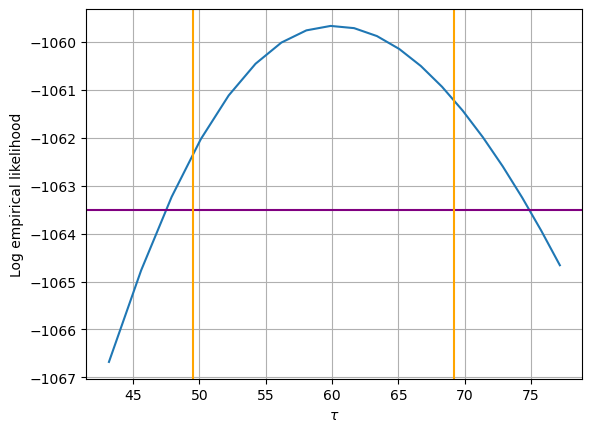

In [28]:
q = dist.chi2(1).ppf(0.95)

plt.grid(True)
plt.plot(np.sqrt(rslt[:, 0]), -rslt[:, 1], "-")
plt.axhline(-rslt[:, 1].min() - q, color="purple")
plt.axvline(np.sqrt(jmn - 2*jse), color="orange")
plt.axvline(np.sqrt(jmn + 2*jse), color="orange")
plt.xlabel(r"$\tau$")
plt.ylabel("Log empirical likelihood")

## E-values

"Expectation values", referred to as [E-values](https://en.wikipedia.org/wiki/E-values), are an emerging way to conduct statistical inference that claims to overcome some of the shortcomings of the dominant inferential approaches based on [p-values](https://en.wikipedia.org/wiki/P-value).  E-values have particular relevance in data integration, since they allow meaningful pooling of evidence under broader conditions that p-values.  At the present time, E-values are still rather new, and they require a fairly distinct way of thinking compared to p-values.  Moreover, there are not yet default or automatic ways to use E-values in all settings where p-values can be used, so it is not realistic to view E-values as a replacement for p-values at the present time.  Here we will give an introduction and some elementary examples of inference using E-values, focusing on applications in data integration and meta-analysis.  For more information, here are links to a comprehensive [ebook](https://stat.cmu.edu/~aramdas/ebook-final.pdf) and an [overview paper](https://www.pnas.org/doi/10.1073/pnas.2302098121).

Like other approaches to statistical inference based on p-values, Z-scores, and false discovery rates, E-values are used in the setting where we have an explicit null hypothesis, and a statistic used to measure evidence against the null hypothesis. The definition of an E value is straightforward -- it is a non-negative statistic whose expected value when the null hypothesis is true is less than or equal to 1.  Analogously, a p-value is a statistic that follows a uniform distribution on $[0, 1]$ when the null hypothesis is true, and a Z-score is a statistic that follows a standard normal distribution when the null hypothesis is true.  Placing a condition on the expectation is much weaker than placing a condition on the distribution, therefore E-values by definition are less constrained than p-values and Z-scores.  In many cases, this makes it easier to construct E-values, and the E-values are generally more robust to assumptions because the requirements imposed on them are weaker.

Thresholds on any evidence scale are somewhat arbitrary, but there is an argument that the reciprocal of an E-value can be viewed as a conservative p-value.  Thus, it is said that $E \ge 20$ is minimal evidence against the null, roughly comparable to $p = 0.05$, and $E \ge 100$ is strong evidence against the null, comparable to $p = 0.01$ or below.

When the null hypothesis is not true, it is desirable for E-values to tend to be larger than 1, and as more data are obtained, we can construct an _E-process_ simply by the E-values.  This simple average meaningfully reflects the aggregation of evidence with increasing sample size.  

An easy way to get started with E-values is to use a _p-to-e calibrator_, which converts p-values to E-values.  The E-values constructed this way are usually not optimal so this tends not to be used much in practice, but it is a way to start building intuition.  Below we consider the p-values for testing the null hypothesis of zero tau-correlation between maternal age and birthweight.  We use a p-to-e calibrator and plot the E-process on the log scale as we consider more and more subpopulations (i.e. as our sample size grows).  The counties are randomly reordered to reflect the fact that there is no fixed ordering to the counties.  We see that after we have observed just a few counties (it varies according to the random permutation), we can be quite confident that maternal age and birthweight are not independent.  The second plot shows what happens when the p-values used to construct the E-values are perfectly uniform on $[0, 1]$ as when the null hypothesis is true.

The use of an E-process here is illustrative of situations where data are obtained sequentially, and we would stop collecting data once we have enough evidence to reject the null hypothesis.  For the NCHS data, all of the data come at once, so this approach is somewhat unnatural here, but we do it for illustration.

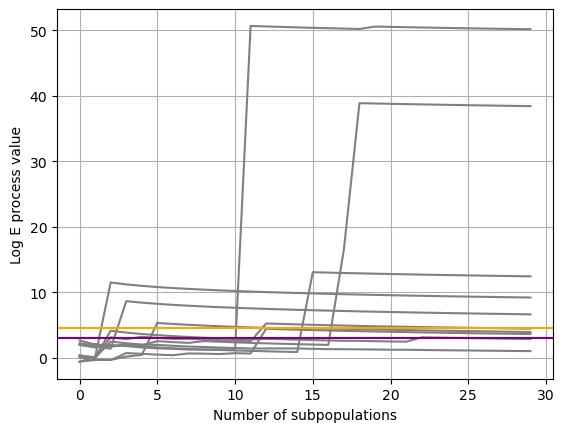

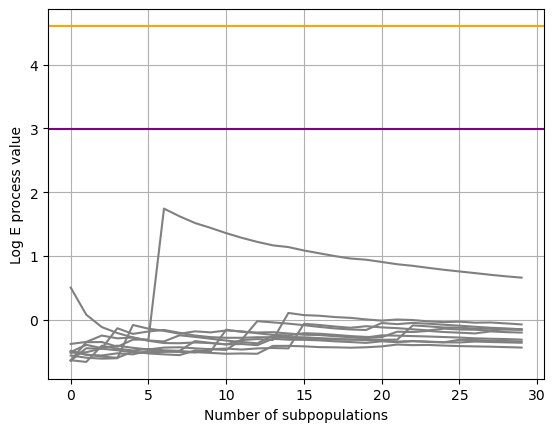

In [29]:
p = dh["p"].values.copy()
for r in [False, True]:
    plt.grid(True)
    for j in range(10):
        if r:
            p = np.random.uniform(size=len(p))
        np.random.shuffle(p)
        E = (1 - p + p*np.log(p)) / (p * np.log(p)**2)
        P = np.log(np.cumsum(E) / np.arange(1, len(E)+1))
        plt.plot(P[0:30], color="grey")
    plt.gca().axhline(np.log(20), color="purple")
    plt.gca().axhline(np.log(100), color="orange")
    plt.xlabel("Number of subpopulations")
    plt.ylabel("Log E process value")
    plt.show()

Now we consider two examples where E-values can be used to assess evidence that a quantitative variable (maternal age or birthweight) follows different distributions in two subpopulations (e.g. comparing girl babies to boy babies).  Here, a more powerful construction can be employed based on the Mann-Whitney U statistic.  This U statistic is asymptotically normal under the null hypothesis, approximately following $U \sim N(\mu, \sigma^2)$.  Since E-values must be non-negative, it is natural to exponentiate the statistic after a suitable scaling and translation, so our E-value will be $E = \exp(b U - b \mu - b^2\sigma^2/2)$.  The statistic $E$ approximately follows a log-normal distrubution, and using the properties of this distribution it can easily be verified that the expected value of $E$ is equal to $1$.  Hence, $E$ is a valid E value.

The constant $b$ in the construction of $E$ is a tuning parameter whose value affects the power but not the validity of the test.  Below we simulate data under the null hypothesis and plot the distribution of the E-values, and calculate the empirical mean which is very close to 1.  By experimentation, it turns out that the E-value is extremely skewed unless $b$ is chosen to be around $c / \sigma$, where $c$ is a constant between roughly 0.1 and 1.  Smaller values of $c$ give a more symmetrically distributed result.  It turns out however that perfect symmetry is not desirable -- a fair amount of right skew improves the "growth rate" of evidence, so values of $c$ from around 0.75 to 1 seem to work best.

0.9927520330147425


Text(0, 0.5, 'Frequency')

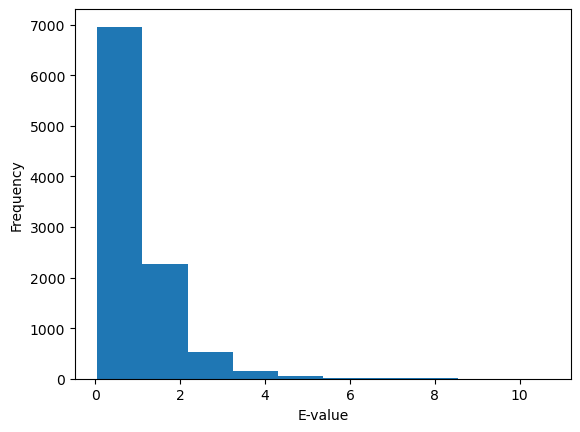

In [30]:
n1 = 50
n2 = 100
nrep = 10000

mu = n1*n2 / 2
s = np.sqrt(n1*n2*(n1+n2+1) / 12)
b = 0.75 / s

u = np.zeros(nrep)
e = np.zeros(nrep)
for i in range(nrep):
    x = np.random.normal(size=n1)
    y = np.random.normal(size=n2)
    u[i] = stats.mannwhitneyu(x, y).statistic
    e[i] = np.exp(b*u[i] - b*mu - (b*s)**2/2)

print(np.mean(e))
plt.hist(e)
plt.xlabel("E-value")
plt.ylabel("Frequency")

We illustrate the use of E-values to compare two distributions using a Mann-Whitney U statistics using the individual-level NCHS data.  Upon selecting a subsample, to illustrate a more challenging power situation, we see that it is easy to achieve strong evidence against the null hypothesis of no sex differences for birthweight but not for maternal age.  Thus, there is strong evidence that birthweights differ by sex, but there is no evidence that maternal age differs by sex.  Since these are all firstborn children, this indicates that there is no evidence of a directional bias in sex ratios between older and younger mothers. 

There are few technical points to consider here.  One is that the construction below is one-sided, so we are only able to detect a setting where male babies are heavier than female babies, or where mothers of male babies are older than mothers of female babies.  It would be straightforward to check for the other direction (which would be found to yield minimal evidence against either of the null hypotheses).  It is also important to note that U-statistics are sensitive to ties, and while there are ways to handle ties, these approaches are tricky to apply.  So instead, here we add a small amount of noise to the data to break all the ties.

In [31]:
nmax = 2000

n1 = nmax
n2 = nmax
mu = n1*n2 / 2
s = np.sqrt(n1*n2*(n1+n2+1) / 12)
b = 0.75 / s

for vname in ["birthweight", "momage"]:
    f = da.query("sex == 'female'")[vname].values[0:nmax]
    m = da.query("sex == 'male'")[vname].values[0:nmax]

    f, m = np.sort(f), np.sort(m)

    # Break the ties
    f = f + 0.1 * np.random.normal(size=nmax)
    m = m + 0.1 * np.random.normal(size=nmax)
    
    u = stats.mannwhitneyu(m, f, method="asymptotic", use_continuity=False).statistic
    v = b*u - b*mu - (b*s)**2/2
    z = (u - mu) / s
    e = np.exp(v)
    print(vname, " ", e)

birthweight   97.75383348461875
momage   1.1443189645478011


## Visual assessment of heterogeneity

We turn now to a more visual way to understand the subpopulation variation in a quantitative outcome such as birthweight.  If we summarize the birthweights using two summary statistics, say a measure of location such as the mean, and a measure of scale such as the standard deviation, we can plot each sub-population as a point in the location x scale plane.  Then for each variable that identifies a subulation (here location, year, sex, and maternal race), we can compute the centroid of all points in the location x scale plane with a given level for each of these four variables.  This allows us to plot each level of each identifying variable as a point in the plane, along with the underlying location and scale values.  In the next cell, we write a function that does this generically, for a given outcome (e.g. birthweight), and for given statistical summaries (e.g. mean and standard deviation).

In [32]:
def summarize_msa(dg, outvar):
    rr = []
    for vname in ["year", "momrace", "sex"]:
        for k,dd in dg.groupby(vname):
            x = dd["x"].mean()
            y = dd["y"].mean()
            n = dd.shape[0]
            rr.append([x, y, n, k])
    rr = pd.DataFrame(rr, columns=["x", "y", "n", "variable"])
    return rr


def flows(da, outvar, stat1_fun, stat1_label, stat2_fun, stat2_label, minsize=500):

    fl = [stat1_fun, stat2_fun]
    dg = da.groupby(["loc", "year", "sex", "momrace"]).agg(x=(outvar, stat1_fun), y=(outvar, stat2_fun), 
                                                                 n=(outvar, lambda x: x.shape[0]))
    dg = dg.reset_index()
    dg = dg.query("n >= @minsize")
    rr = summarize_msa(dg, outvar)

    xmin, xmax = rr["x"].min(), rr["x"].max()
    ymin, ymax = rr["y"].min(), rr["y"].max()
    dx = 0.05 * (xmax - xmin)
    xmin -= dx
    xmax += dx
    dy = 0.05 * (ymax - ymin)
    ymin -= dy
    ymax += dy

    rect = patches.Rectangle((xmin, ymin), width=xmax-xmin, height=ymax-ymin, 
                         edgecolor='red', facecolor='none', linewidth=2)
    
    plt.grid(True)
    plt.plot(dg["x"], dg["y"], "o", color="grey", alpha=0.1)
    plt.gca().add_patch(rect)
    plt.xlabel(stat1_label)
    plt.ylabel(stat2_label)
    plt.show()

    plt.grid(True)
    plt.plot(dg["x"], dg["y"], "o", color="grey", alpha=0.1)
    for k in range(rr.shape[0]):
        plt.text(rr["x"].iloc[k], rr["y"].iloc[k], rr["variable"].iloc[k], 
                 horizontalalignment="center", verticalalignment="center")
    w = dg["n"]
    w /= w.sum()
    sx = np.dot(dg["x"], w)
    sy = np.dot(dg["y"], w)
    plt.plot(sx, sy, "o", color="red")
    plt.xlim((xmin, xmax))
    plt.ylim((ymin, ymax))
    plt.xlabel(stat1_label)
    plt.ylabel(stat2_label)

    return dg

Now we illustrate the approach using the sample mean and sample standard deviation to characterize the distribution of birthweights for each sub-population.  The first plot shows only the mean and standard deviation values, along with a box that will form the boundaries of the subsequent plot, which shows the centroids as described above.  This plot shows that the Black subpopulations have lower mean and higher standard deviation, while the Asian subpopulations have lower mean and lower standard deviation.  The female populations have lower mean and lower standard deviation, while the male subpopulations have higher mean and higher standard deviation.  There is very little difference between the later three years, but birthweights in 1971 were lower and less heterogeneous.

/tmp/ipykernel_3109168/1434802729.py:16: FutureWarning: The provided callable <function mean at 0x14a2a0093380> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  dg = da.groupby(["loc", "year", "sex", "momrace"]).agg(x=(outvar, stat1_fun), y=(outvar, stat2_fun),
/tmp/ipykernel_3109168/1434802729.py:16: FutureWarning: The provided callable <function std at 0x14a2a00934c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  dg = da.groupby(["loc", "year", "sex", "momrace"]).agg(x=(outvar, stat1_fun), y=(outvar, stat2_fun),


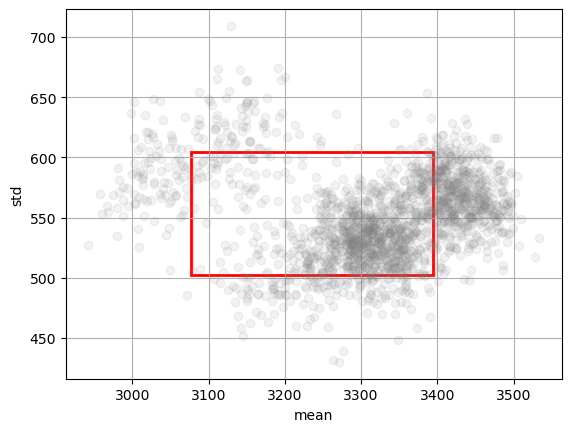

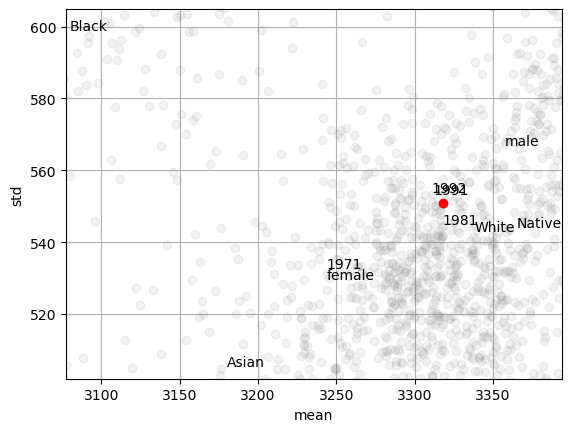

In [33]:
flows(da, "birthweight", np.mean, "mean", np.std, "std");

We provide a second illustration using measures of skewness and kurtosis based on [L-moments](https://en.wikipedia.org/wiki/L-moment).  Like the more familiar [skewness](https://en.wikipedia.org/wiki/Skewness) based on classical [moments](https://en.wikipedia.org/wiki/Moment_(mathematics)), the L-skewness is positive if the right tail is heavier than the left tail, and is negative if the left tail is heavier than the right tail.  The L-kurtosis is a measure of symmetric heaviness of the tails.  For reference, the Gaussian distribution has L-kurtosis that is approximately equal to 0.12. 

In [34]:
from scipy.special import comb

def l2(x):
    x = np.sort(x)
    n = len(x)
    ix = np.arange(n)
    m = np.dot(x, comb(ix, 1) - comb(n-ix-1, 1))
    m /= (2 * comb(n, 2))
    return m

def l3(x):
    x = np.sort(x)
    n = len(x)
    ix = np.arange(n)
    m = np.dot(x, comb(ix, 2) - 2*comb(ix, 1)*comb(n-ix-1, 1) + comb(n-ix-1, 2))
    m /= (3 * comb(n, 3))
    return m

def l4(x):
    x = np.sort(x)
    n = len(x)
    ix = np.arange(n)
    m = np.dot(x, comb(ix, 3) - 3*comb(ix, 2)*comb(n-ix-1, 1) + 3*comb(ix, 1)*comb(n-ix-1, 2) - comb(n-ix-1, 3))
    m /= (4 * comb(n, 4))
    return m

The results indicate a substantial inverse relationship between the L-skewness and the L-kurtosis.  While nearly all sub-populations have negative L-skewness, those sub-populations that are closest to being symmetric (L-skewness close to zero) have the smallest L-kurtosis, approaching that of a Gaussian distribution. Sub-populations corresponding to Black individuals tend to have lower (more negative) skewness and higher kurtosis.

/tmp/ipykernel_3109168/318718669.py:16: RuntimeWarning: invalid value encountered in scalar divide
  m /= (3 * comb(n, 3))
/tmp/ipykernel_3109168/318718669.py:8: RuntimeWarning: invalid value encountered in scalar divide
  m /= (2 * comb(n, 2))
/tmp/ipykernel_3109168/318718669.py:24: RuntimeWarning: invalid value encountered in scalar divide
  m /= (4 * comb(n, 4))


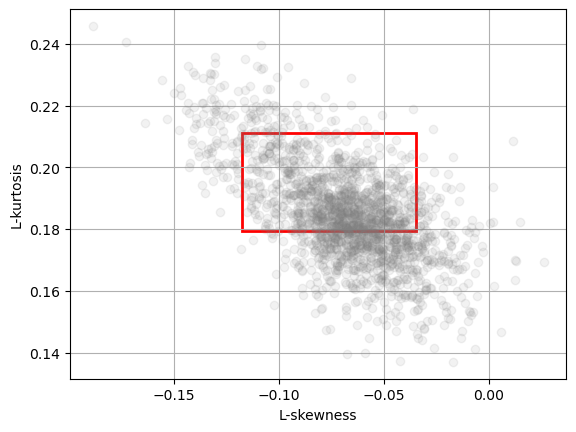

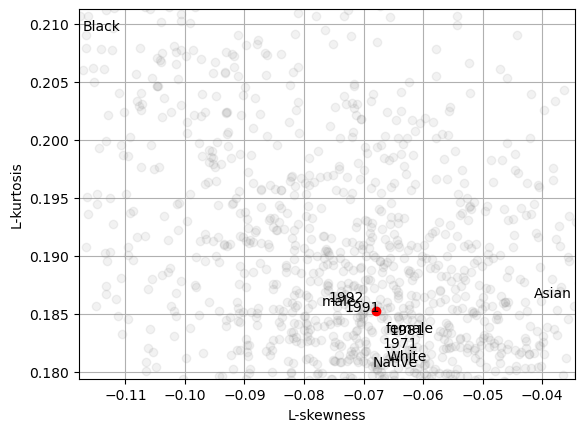

In [35]:
tau3 = lambda x: l3(x) / l2(x)
tau4 = lambda x: l4(x) / l2(x)
dg = flows(da, "birthweight", tau3, "L-skewness", tau4, "L-kurtosis")

## Variance component analysis

Variance component analysis is a special type of random effects or multilevel modeling that arises when the explanatory variables are all categorical.  We can use it to gain some insights into our aggregated data, in order to see which factors (year, sex, maternal race, and location) explain the most variation in an outcome (birthweight or maternal age).  

One way to approach variance components analysis is through fully-specified models, but the notation and language for describing more complex multilevel models gets quite complex.  Also, most variance components analysis is conducted using restricted maximum likelihood (RMLE) methods that are supported in statistical packages such as the lmer package in R (similarly powerful capabilities exist for SAS, Stata, and Julia).  Although the Python Statsmodels package can fit certain types of linear multilevel models, it lacks capabilities comparable to R.  Moreover, there are reasons to consider alternative estimators, since, among other issues, the RMLE approach takes the random effects to be Gaussian, an assumption that is difficult to test, and it is difficult to account for complex heteroscedasticity.  There are a number of alternative estimators for variance components models, including the [MINQUE](https://en.wikipedia.org/wiki/MINQUE) approach, as well as Bayesian approaches.  

Here we adopt a method of moments approach based on U statistics. An advantage of this approach is that it allows us to directly target variance parameters of interest without explicitly specifying a complete model for the data.  Also, it can accommodate arbitrary known heteroscedasticity.  For illustration, we focus on a few interesting cases below related to "idiosyncratic" race and sex differences, and illustrate how the parameters of interest can be estimated using just a few lines of code.

Our data are partitioned into thousands of groups, each determined by a combination of location, year, sex, and maternal race.  There can be systematic "main effects" for year, sex, and maternal race, as these variables have a small number of distinct levels (no more than four).  Location effects would be difficult to model using fixed main effects since there are thousands of counties.  As a first illustration, we focus on "idiosyncratic" maternal race differences, where by "idiosyncratic" we mean maternal race differences that are unique to each subpopulation (race differences that are common to all subpopulations are captured through the race fixed effects).  To do so, we first residualize the data to eliminate the fixed main effects of year, sex, and maternal race.  We then look within each stratum, defined by location, year, and sex, but not stratifying on maternal race.  Within each such stratum, we have sample means for up to four races.  The squared difference between any two of these means is informative for the idiosyncratic race effect.  Similar to above, the raw squared difference between sample means needs to be adjusted downward for the inflation caused by imprecision in the mean estimates, and this is straightforward to do.  These squared differences are aggregated over all race pairs, and over all subpopulations defined by location, year, and sex.  This makes this a method of moments approach emplyoying U statistics.

The approach described here is unbiased, and does not require the data to follow any particular distribution.  It is less statistically efficient than the RMLE approach when the model is correctly specified, but more robust to misspecification of this model.  Below we implement a generic function that calculates the idiosyncratic effects for outcome "outvar" between levels of "varvar", stratifying on the variables in "groupvars".

In [36]:
def varcomp(outvar, varvar, groupvars):

    da1 = da.copy()
    m0 = sm.OLS.from_formula(f"{outvar} ~ C(year) + sex + momrace", da1)
    r0 = m0.fit()
    print(r0.summary())
    da1["resid"] = r0.resid.values
    
    dg = da1.groupby([varvar] + groupvars)["resid"].agg(["mean", "std", "size"]).reset_index()
    dg = dg.query("size >= 50").copy() # need copy to avoid SettingWithCopyWarning
    dg["se"] = dg["std"] / np.sqrt(dg["size"])

    U = 0.0
    n = 0
    for (ky,dx) in dg.groupby(groupvars):
        mn = dx["mean"].values
        se = dx["se"].values
        for i in range(dx.shape[0]):
            for j in range(i+1, dx.shape[0]):
                U += (mn[i] - mn[j])**2 - se[i]**2 - se[j]**2
                n += 1
    U /= (2 * n)
    return np.sqrt(U if U >= 0 else 0)

The results below show that there is around 32 grams of idiosyncratic birthweight standard deviation between maternal races, within county x year x sex subpopulations.  This is about 1/8 of the largest between race fixed difference.  We might interpret this to indicate that the relationship between birthweight and race is largely systematic, although there does seem to be additional idiosyncratic variation that is about an order of magnitude smaller than the stable differences.  The results for maternal age are similar -- the idiosyncratic variation is around 20% of the stable variation.

In [37]:
for vname in ["birthweight", "momage"]:
    s = varcomp(vname, "momrace", ["loc", "year", "sex"])
    print("\nIdiosyncratic SD for %s:\n %12.5f" % (vname, s))

                            OLS Regression Results                            
Dep. Variable:            birthweight   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 2.479e+04
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:41:28   Log-Likelihood:            -3.4611e+07
No. Observations:             4474401   AIC:                         6.922e+07
Df Residuals:                 4474393   BIC:                         6.922e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          3074.2899      1.68

As a second example, we can look for stable and idiosyncratic differences in maternal age and birthweight with respect to offspring sex.    For birthweight, the stable differences reflect differences in average weight between groups, which are understood to some extent (e.g. male babies are heavier than female babies, and birthweights have been trending upwards over time).  The idiosyncratic differences would reflect whether sex differences are heterogeneous across strata defined by year, maternal race, and location.  The idiosyncratic differences in birthweight due to sex are small, only round 5% of the stable sex difference.  Thus the difference in average weight between male and female babies seems to be mostly invariant to other factors.

Maternal age is arguably a negative control here, we would expect no sex differences in maternal age.  This is true for both stable variation, since the main effect for sex is not significantly different from zero, and for idiosyncratic variation, whose variance parameter is estiamted to be negative (it is rounded up to zero when converting to a standard deviation).

In [38]:
for vname in ["birthweight", "momage"]:
    s = varcomp(vname, "sex", ["loc", "year", "momrace"])
    print("\nIdiosyncratic SD for %s:\n %12.5f" % (vname, s))

                            OLS Regression Results                            
Dep. Variable:            birthweight   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 2.479e+04
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:43:32   Log-Likelihood:            -3.4611e+07
No. Observations:             4474401   AIC:                         6.922e+07
Df Residuals:                 4474393   BIC:                         6.922e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          3074.2899      1.68

KeyboardInterrupt: 

## Data integration over time

Another form of heterogeneity is heterogeneity over time, which might also be referred to as "non-stationarity".  In this section we illustrate how the results of regression analyses can systematically be compared across years.  We use quantile regression models for the 0.1 probability point, since many research questions center on low birthweight.  We fit a separate model for each year of data.  Since we will use paternal age as a predictor of birthweight, we drop all observations with missing paternal age.

In [ ]:
# Drop observations with missing paternal age
da1 = da.loc[da["dadage"].notnull(), :]

# Create centered versions of parental age variables
momage_ref = 25
dadage_ref = 25
da1["momage_cen"] = da1["momage"] - momage_ref
da1["dadage_cen"] = da1["dadage"] - dadage_ref

# Estimate the quantiles using this predictor structure
fml = "birthweight ~ sex + momage + I(momage_cen**2) + dadage + I(dadage_cen**2)"

rq = []
for (k,dx) in da1.groupby("year"):
    m = sm.QuantReg.from_formula(fml, data=dx)
    r = m.fit(q=0.1)
    rq.append(r)

When considering changes over time, we can focus on changes in the marginal distribution of the outcome $P(Y)$, changes in the marginal distribution of the predictors $P(X)$, and changes in the conditional distribution of the outcome given the predictors $P(Y|X)$.  Changes in $P(Y|X)$ are often most interesting, but changes in $P(X)$, known as "distribution shift" are important to consider as well.  For example, below we see that both mothers and fathers are older in more recent years, a form of distribution shift.  But as expected there is no meaningful distribution shift in sex.

In [ ]:
da1["female"] = da1["sex"] == "female"
da1.groupby("year").agg({"momage": "mean", "dadage": "mean", "female": "mean"})

To assess changes in $P(Y)$, we will use a quantile-quantile (QQ) plot to compare the marginal distributions of birthweights in 1971 and 1991. The result suggests a "location shift", in which at each quantile, the 1991 birthweights are greater by about 60 grams.

In [ ]:
pp = np.linspace(0.1, 0.9, 9)
q71 = np.quantile(da1.query("year == 1971")["birthweight"], pp)
q91 = np.quantile(da1.query("year == 1991")["birthweight"], pp)

plt.grid(True)
plt.plot(q71, q91)
plt.xlabel("1971")
plt.ylabel("1991")
plt.axline((3000, 3000), slope=1, color="grey")
(q91 - q71).mean()

Now we turn to comparing the two models for birthweight. One approach would be to compare the coefficients.  It appears that the difference between female and male birthweights is declining, but it is more difficult to interpret the changes to the polynomial basis coefficients, since the two basis functions for each parent work together.

In [ ]:
cf = pd.DataFrame([r.params for r in rq], index=years)
cf

An approach that is sometimes useful is to consider the difference in fitted values, and the standardized difference in fitted values.  Let $\hat{\beta}_1$ and $\hat{\beta}_2$ be independent estimates of the parameters from two models fit to independent datasets, with $\Psi_1$ and $\Psi_2$ their corresponding covariance matrices.  For any subject with covariate vector $x$, the difference in fitted values is $x^\prime (\hat{\beta}_1 - \hat{\beta}_2)$, and the standardized difference is $x^\prime (\hat{\beta}_1 - \hat{\beta}_2) / \sqrt{x^\prime (\Psi_1 + \Psi_2) x}$.

Comparing 1981 to 1971, we see that there are no people for whom the 1981 prediction is significantly less than the 1971 prediction, but there are many cases where the 1981 prediction is significantly greater than the 1971 prediction, with the prediction being up to 300 grams greater in some cases.

In [ ]:
cc = {year: r.cov_params() for (year,r) in zip(years, rq)}

def compare_years(y1, y2):
    C = cc[y1] + cc[y2]
    cd = cf.loc[y1] - cf.loc[y2]
    j = years.index(y1)
    X = rq[j].model.exog
    F = rq[j].model.data.frame[["sex", "momage", "momage_cen", "dadage", "dadage_cen"]].copy()

    zdiff = np.zeros(X.shape[0])
    pdiff = np.zeros(X.shape[0])    
    for i in range(X.shape[0]):
        x = X[i, :]
        pdiff[i] = np.dot(x, cd)
        zdiff[i] = pdiff[i] / np.sqrt(np.dot(x, np.dot(C, x))) 
    F["pdiff"] = pdiff
    F["zdiff"] = zdiff
    
    return F

F = compare_years(1981, 1971)

plt.grid(True)
plt.plot(F["zdiff"], F["pdiff"], "o", alpha=0.2)
plt.xlabel("Standardized difference of predicted values")
plt.ylabel("Difference of predicted values")

These are the people with the most extreme standardized differences:

In [ ]:
F = F.sort_values(by="zdiff")
print(F.head())
print(F.tail())

These are the people with the most extreme raw differences:

In [ ]:
F = F.sort_values(by="pdiff")
print(F.head())
print(F.tail())